# K-Nearest Neighbors (KNN)

## Objective

- Understand the principles of the K-Nearest Neighbors algorithm.
- Learn the role of distance metrics in classification.
- Implement KNN from scratch using NumPy.
- Build a KNN classifier using Scikit-learn.
- Evaluate model performance using classification metrics.
- Analyze the effect of different values of K.

# Dataset Information

**Dataset Name:** Iris Dataset

**Kaggle Link:**
https://www.kaggle.com/datasets/uciml/iris

**Reason for Selection:**
The Iris dataset is a real-world, multi-class classification dataset widely used in machine learning education. It is particularly suitable for demonstrating KNN because classification is based on similarity between flower measurements.

**Target Variable:** `Species`

- Iris-setosa
- Iris-versicolor
- Iris-virginica

**Credits:** Kaggle

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

In [21]:
# Load dataset
df = pd.read_csv("dataset/iris.csv")

# Display first 5 rows
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


## Dataset Exploration

Before training the KNN model, we explore the dataset structure, check the class distribution, and identify any missing values.

In [22]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nSpecies Distribution:")
print(df['Species'].value_counts())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nSummary Statistics:")
display(df.describe())

Dataset Shape: (150, 6)

Column Names:
['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm', 'Species']

Species Distribution:
Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

Missing Values:
Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

Summary Statistics:


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


## Data Preprocessing

The `Id` column is removed because it does not contribute to prediction. The target variable is encoded into numerical values. The dataset is then split into training and testing sets. Since KNN relies on distance calculations, feature scaling is performed using StandardScaler.

In [23]:
# Remove unnecessary column
if 'Id' in df.columns:
    df = df.drop('Id', axis=1)

# Encode target variable
df['Species'] = df['Species'].replace({
    'Iris-setosa': 0,
    'Iris-versicolor': 1,
    'Iris-virginica': 2
})

# Features
X = df.drop('Species', axis=1)

# Target
y = df['Species']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Feature Scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training Feature Shape:", X_train_scaled.shape)
print("Testing Feature Shape:", X_test_scaled.shape)

print("Training Target Shape:", y_train.shape)
print("Testing Target Shape:", y_test.shape)

print("\nEncoded Class Distribution:")
print(y.value_counts().sort_index())

Training Feature Shape: (120, 4)
Testing Feature Shape: (30, 4)
Training Target Shape: (120,)
Testing Target Shape: (30,)

Encoded Class Distribution:
Species
0    50
1    50
2    50
Name: count, dtype: int64


In [35]:
# Convert target to integer type
y = y.astype(int)

# Train-test split again
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Feature Scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(y_train.dtype)
print(y_train.unique())

int64
[0 2 1]


## K-Nearest Neighbors: From Scratch (NumPy)

In this section, we implement KNN from scratch using NumPy. The algorithm classifies a new data point by identifying the K nearest training samples based on Euclidean distance and selecting the majority class among them.

In [24]:
def euclidean_distance(x1, x2):

    return np.sqrt(
        np.sum((x1 - x2) ** 2)
    )

In [29]:
def predict_knn(X_train, y_train, X_test, k=5):

    predictions = []

    for test_point in X_test:

        distances = []

        for i in range(len(X_train)):

            distance = euclidean_distance(
                test_point,
                X_train[i]
            )

            distances.append(
                (distance, int(y_train[i]))
            )

        distances.sort(
            key=lambda x: x[0]
        )

        neighbors = distances[:k]

        labels = [
            int(label) for _, label in neighbors
        ]

        prediction = Counter(
            labels
        ).most_common(1)[0][0]

        predictions.append(
            int(prediction)
        )

    return np.array(predictions, dtype=int)

In [30]:
y_train_np = y_train.astype(int).values
y_test_np = y_test.astype(int).values

scratch_predictions = predict_knn(
    X_train_scaled,
    y_train_np,
    X_test_scaled,
    k=5
)

print("Predictions:", scratch_predictions[:10])
print("Actual:", y_test_np[:10])

scratch_accuracy = accuracy_score(
    y_test_np,
    scratch_predictions
)

print(
    "Scratch Implementation Accuracy:",
    round(scratch_accuracy, 4)
)

Predictions: [0 2 1 1 0 1 0 0 2 1]
Actual: [0 2 1 1 0 1 0 0 2 1]
Scratch Implementation Accuracy: 0.9333


## Species Distribution

This visualization shows the number of samples belonging to each Iris species.

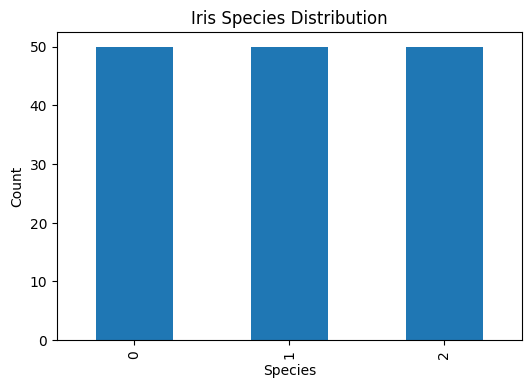

In [36]:
plt.figure(figsize=(6, 4))

df['Species'].value_counts().plot(
    kind='bar'
)

plt.title(
    'Iris Species Distribution'
)

plt.xlabel(
    'Species'
)

plt.ylabel(
    'Count'
)

plt.show()

## Hyperparameter Experiment

The value of K significantly influences KNN performance. Here, we evaluate multiple K values to identify their impact on accuracy.

In [34]:
print(y_train.dtype)
print(y_train.unique())

object
[0 2 1]


In [37]:
k_values = [1, 3, 5, 7, 9]

for k in k_values:

    experiment_model = KNeighborsClassifier(
        n_neighbors=k
    )

    experiment_model.fit(
        X_train_scaled,
        y_train
    )

    predictions = experiment_model.predict(
        X_test_scaled
    )

    score = accuracy_score(
        y_test,
        predictions
    )

    print(
        f"K = {k}: Accuracy = {score:.4f}"
    )

K = 1: Accuracy = 0.9667
K = 3: Accuracy = 0.9333
K = 5: Accuracy = 0.9333
K = 7: Accuracy = 0.9667
K = 9: Accuracy = 0.9667


## Interview Corner

### Question:
Why is feature scaling important in KNN?

### Answer:
KNN relies on distance calculations to identify nearest neighbors. If features have different scales, variables with larger ranges can dominate the distance metric, leading to biased predictions. Feature scaling ensures that all features contribute equally.

## Euclidean Distance Formula

Euclidean Distance is commonly used in KNN to measure similarity between data points.

d = √Σ(xᵢ − yᵢ)²

Where:

- d = Distance between two observations
- xᵢ = Feature value of the first observation
- yᵢ = Feature value of the second observation

### Significance

The nearest neighbors are selected based on the smallest Euclidean distances.

## Key Takeaways

1. KNN is a supervised learning algorithm used for classification and regression tasks.
2. Predictions are based on the majority class among the nearest neighbors.
3. Feature scaling is essential because KNN relies on distance metrics.
4. Both NumPy and Scikit-learn implementations help build conceptual understanding.
5. The choice of K significantly affects model performance.
6. Hyperparameter tuning can improve classification accuracy.
7. Multi-class datasets like Iris demonstrate the flexibility of KNN.

## Workflow Diagram

![KNN Workflow](images/workflow.png)